# Time-MMD abrupt distribution shift explorer

이 노트북은 **전체 도메인 데이터셋**을 순회하면서,  
입력 구간(`seq_len`)과 미래 예측 구간(`pred_len`) 사이의 **분포 변화가 큰 구간**을 통계적으로 찾기 위한 분석용 노트북입니다.

핵심 아이디어는 다음과 같습니다.

- 입력 윈도우와 미래 호라이즌의 **평균 / 분산 / 분포 / 추세** 차이를 계산
- 각 윈도우에 대해 **shift score**를 만들고
- score가 큰 구간을 **갑작스러운 시계열 변화 구간**으로 간주하여 리스트업
- 최종적으로 도메인별 / 호라이즌별 비교와 개별 시각화를 지원

> 목적: “예측이 어려워 보이는 구간”, “입력 패턴으로부터 곧바로 설명되지 않는 미래 분포 변화 구간”을 찾기


In [21]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, wasserstein_distance

from configs.domains import DOMAIN_CONFIG
from src.datasets.timemmd_dataset import load_domain_csv, TARGET_COL

plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [22]:
# 기본 경로
REPO_ROOT = Path(".").resolve()
DATA_ROOT = REPO_ROOT / "data" / "Time-MMD" / "numerical"

# 이상 구간을 고르는 기준
TOP_K_PER_SETTING = 30          # 각 (domain, pred_len) 조합에서 상위 몇 개를 볼지
PERCENTILE_THRESHOLD = 97.5     # composite score 상위 퍼센타일
ROBUST_Z_THRESHOLD = 3.5        # MAD 기반 robust z-score threshold

print("REPO_ROOT:", REPO_ROOT)
print("DATA_ROOT:", DATA_ROOT)

REPO_ROOT: /home/alsgh6545/NAS/PMH/Time-mmd_only_TS
DATA_ROOT: /home/alsgh6545/NAS/PMH/Time-mmd_only_TS/data/Time-MMD/numerical


## 1. Shift score 정의

각 윈도우에서 다음 지표를 계산합니다.

- `mean_shift`: 입력 평균과 미래 평균 차이
- `std_shift`: 입력 표준편차와 미래 표준편차 차이
- `ks_stat`: 입력/미래가 같은 분포인지 보는 KS 통계량
- `wasserstein`: 분포 간 이동 거리
- `slope_shift`: 입력 추세와 미래 추세 차이
- `jump_score`: 입력 마지막 값과 미래 첫 값 사이의 불연속 점프
- `range_shift`: 진폭(range) 차이

이후 각 지표를 robust scaling(MAD 기반)으로 정규화한 뒤 평균내어 `composite_shift_score`를 만듭니다.


In [23]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance


def safe_std(x: np.ndarray, eps: float = 1e-8) -> float:
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanstd(x) + eps)


def local_slope(x: np.ndarray, k: int = 5) -> float:
    x = np.asarray(x, dtype=np.float64)

    if len(x) < 2:
        return 0.0
    if not np.isfinite(x).all():
        return 0.0

    k = min(k, len(x))
    if k < 2:
        return 0.0

    return float((x[-1] - x[-k]) / (k - 1))


def drift_forecast_error(x: np.ndarray, y: np.ndarray, m: int = 5) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    if len(x) < 2 or len(y) < 1:
        return 0.0
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        return 0.0

    m = min(m, len(x))
    if m < 2:
        slope = 0.0
    else:
        slope = (x[-1] - x[-m]) / (m - 1)

    y_hat = x[-1] + slope * np.arange(1, len(y) + 1, dtype=np.float64)
    return float(np.mean(np.abs(y - y_hat)))


def residual_burst_score(x: np.ndarray, y: np.ndarray, k: int = 5) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    if len(x) < 2 or len(y) < 2:
        return 0.0
    if not np.isfinite(x).all() or not np.isfinite(y).all():
        return 0.0

    x_trend = local_slope(x, k=k)
    y_trend = local_slope(y, k=min(k, len(y)))

    x_idx = np.arange(len(x), dtype=np.float64)
    y_idx = np.arange(len(y), dtype=np.float64)

    x_base = x[0] + x_trend * x_idx
    y_base = y[0] + y_trend * y_idx

    x_resid = x - x_base
    y_resid = y - y_base

    return float(abs(np.std(y_resid) - np.std(x_resid)))


def robust_zscore(series: pd.Series, eps: float = 1e-8) -> pd.Series:
    med = series.median()
    mad = np.median(np.abs(series - med))
    return 0.6745 * (series - med) / (mad + eps)


def make_window_metrics(
    target_values: np.ndarray,
    start_dates,
    end_dates,
    seq_len: int,
    pred_len: int
) -> pd.DataFrame:
    rows = []
    total = len(target_values) - seq_len - pred_len + 1

    if total <= 0:
        return pd.DataFrame()

    for idx in range(total):
        x = target_values[idx: idx + seq_len].astype(np.float64)
        y = target_values[idx + seq_len: idx + seq_len + pred_len].astype(np.float64)

        if len(x) < 2 or len(y) < 1:
            continue
        if not np.isfinite(x).all() or not np.isfinite(y).all():
            continue

        x_std = safe_std(x)
        y_std = safe_std(y)

        x_mean = float(np.mean(x))
        y_mean = float(np.mean(y))

        # Distribution
        mean_shift = abs(y_mean - x_mean) / x_std
        volatility_shift = abs(y_std - x_std) / x_std
        wasserstein = float(wasserstein_distance(x, y)) / x_std

        # Structural break
        x_trend = local_slope(x, k=5)
        y_trend = local_slope(y, k=min(5, len(y)))
        trend_mismatch = abs(y_trend - x_trend) / x_std
        residual_burst = residual_burst_score(x, y, k=5) / x_std

        # Forecast failure
        drift_error = drift_forecast_error(x, y, m=5) / x_std

        rows.append({
            "window_idx": idx,
            "input_start_date": pd.to_datetime(start_dates[idx]) if start_dates is not None else pd.NaT,
            "input_end_date": pd.to_datetime(end_dates[idx + seq_len - 1]) if end_dates is not None else pd.NaT,
            "target_start_date": pd.to_datetime(start_dates[idx + seq_len]) if start_dates is not None else pd.NaT,
            "target_end_date": pd.to_datetime(end_dates[idx + seq_len + pred_len - 1]) if end_dates is not None else pd.NaT,

            "input_mean": x_mean,
            "target_mean": y_mean,
            "input_std": x_std,
            "target_std": y_std,

            "mean_shift": mean_shift,
            "volatility_shift": volatility_shift,
            "wasserstein": wasserstein,
            "trend_mismatch": trend_mismatch,
            "residual_burst": residual_burst,
            "drift_error": drift_error,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # metric-wise normalization
    metric_cols = [
        "mean_shift",
        "volatility_shift",
        "wasserstein",
        "trend_mismatch",
        "residual_burst",
        "drift_error",
    ]

    for col in metric_cols:
        df[f"{col}_rz"] = robust_zscore(df[col].astype(float)).fillna(0.0)

    # group scores
    dist_cols = [
        "mean_shift_rz",
        "volatility_shift_rz",
        "wasserstein_rz",
    ]
    struct_cols = [
        "trend_mismatch_rz",
        "residual_burst_rz",
    ]
    forecast_cols = [
        "drift_error_rz",
    ]

    df["distribution_score"] = df[dist_cols].mean(axis=1)
    df["structural_break_score"] = df[struct_cols].mean(axis=1)
    df["forecast_failure_score"] = df[forecast_cols].mean(axis=1)

    # final weighted score
    df["composite_shift_score"] = (
        0.2 * df["distribution_score"]
        + 0.4 * df["structural_break_score"]
        + 0.4 * df["forecast_failure_score"]
    )

    percentile_cut = np.percentile(df["composite_shift_score"], PERCENTILE_THRESHOLD)
    df["is_extreme_by_percentile"] = df["composite_shift_score"] >= percentile_cut
    df["is_extreme_by_robust_z"] = df["composite_shift_score"] >= ROBUST_Z_THRESHOLD
    df["is_extreme"] = df["is_extreme_by_percentile"] | df["is_extreme_by_robust_z"]

    return df

In [24]:
import numpy as np
import pandas as pd

eda_rows = []

for domain, cfg in DOMAIN_CONFIG.items():
    csv_path = DATA_ROOT / cfg["csv"]

    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"[ERROR] {domain}: {e}")
        continue

    if TARGET_COL not in df.columns:
        print(f"[NO TARGET] {domain}")
        continue

    x = df[TARGET_COL].values

    eda_rows.append({
        "domain": domain,
        "len": len(x),
        "nan_count": int(np.isnan(x).sum()),
        "inf_count": int(np.isinf(x).sum()),
        "nan_ratio": float(np.isnan(x).mean()),
        "min": float(np.nanmin(x)),
        "max": float(np.nanmax(x)),
        "mean": float(np.nanmean(x)),
        "std": float(np.nanstd(x)),
    })

eda_df = pd.DataFrame(eda_rows).sort_values("nan_ratio", ascending=False)
eda_df

,domain,len,nan_count,inf_count,nan_ratio,min,max,mean,std
0,Agriculture,532,0,0,0.0,88.235892,2.541739e+02,1.616765e+02,3.446158e+01
1,Climate,1272,0,0,0.0,27.620000,9.150000e+01,5.683098e+01,1.163177e+01
2,Economy,447,0,0,0.0,-116661.700000,-1.888500e+03,-4.511408e+04,2.794579e+04
3,Energy,1622,0,0,0.0,0.949000,5.107000e+00,2.356562e+00,9.510386e-01
4,Environment,15979,0,0,0.0,13.000000,2.790000e+02,7.900175e+01,4.036752e+01
5,Health_US,1389,0,0,0.0,0.000000,7.797830e+00,1.803243e+00,1.374455e+00
6,Security,309,0,0,0.0,805651.000000,2.035772e+10,8.037967e+08,1.480849e+09
7,SocialGood,916,0,0,0.0,2.400000,1.440000e+01,5.697271e+00,1.750522e+00
8,Traffic,651,0,0,0.0,77442.000000,2.943280e+05,1.973492e+05,5.927136e+04


## 2. 전체 도메인 순회 분석

In [25]:
all_results = []
summary_rows = []

for domain, cfg in DOMAIN_CONFIG.items():
    csv_path = DATA_ROOT / cfg["csv"]
    seq_len = int(cfg["seq_len"])

    df = load_domain_csv(csv_path)
    target = df[TARGET_COL].values.astype(np.float32)
    start_dates = df["start_date"].values if "start_date" in df.columns else None
    end_dates = df["end_date"].values if "end_date" in df.columns else None

    for pred_len in cfg["pred_lens"]:
        res = make_window_metrics(
            target_values=target,
            start_dates=start_dates,
            end_dates=end_dates,
            seq_len=seq_len,
            pred_len=int(pred_len),
        )

        if res.empty:
            continue

        res["domain"] = domain
        res["pred_len"] = int(pred_len)
        res["seq_len"] = seq_len
        res["seq_to_pred_ratio"] = seq_len / pred_len

        all_results.append(res)

        summary_rows.append({
            "domain": domain,
            "seq_len": seq_len,
            "pred_len": int(pred_len),
            "num_windows": len(res),
            "num_extreme": int(res["is_extreme"].sum()),
            "extreme_ratio": float(res["is_extreme"].mean()),
            "score_mean": float(res["composite_shift_score"].mean()),
            "score_std": float(res["composite_shift_score"].std()),
            "score_p95": float(np.percentile(res["composite_shift_score"], 95)),
            "score_p99": float(np.percentile(res["composite_shift_score"], 99)),
        })

results_df = pd.concat(all_results, ignore_index=True)
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["score_p99", "extreme_ratio"], ascending=False
).reset_index(drop=True)

print("Total windows:", len(results_df))
print("Total extreme windows:", int(results_df["is_extreme"].sum()))
summary_df.head(20)

Total windows: 90512
Total extreme windows: 2572


,domain,seq_len,pred_len,num_windows,num_extreme,extreme_ratio,score_mean,score_std,score_p95,score_p99
0,Security,8,12,290,25,0.086207,0.946201,2.931110,4.801663,17.041204
1,SocialGood,8,12,897,32,0.035674,0.596142,2.218211,2.836813,11.723832
2,SocialGood,8,10,899,23,0.025584,0.421387,1.826118,2.021448,10.657051
3,Security,8,10,292,23,0.078767,1.000554,3.982300,4.490828,10.531684
4,Security,8,8,294,26,0.088435,0.870539,2.655017,4.954669,9.403547
5,Security,8,6,296,24,0.081081,0.699967,1.931157,5.494428,8.497919
6,Health_US,36,48,1306,79,0.060490,0.782121,1.710984,3.775995,7.865050
7,Agriculture,8,12,513,32,0.062378,0.599686,1.592429,4.384121,7.484258
8,Agriculture,8,10,515,32,0.062136,0.602734,1.662389,4.021277,7.286931
9,SocialGood,8,8,901,23,0.025527,0.414696,1.865649,1.988229,6.789883


In [ ]:

# =========================
# Extreme windows -> episodes
# =========================

EPISODE_GAP = 0
TOP_K_EPISODES_PER_SETTING = TOP_K_PER_SETTING

def merge_extreme_windows_into_episodes(
    df: pd.DataFrame,
    group_cols=("domain", "pred_len"),
    score_col="composite_shift_score",
    extreme_col="is_extreme",
    gap: int = 0,
) -> pd.DataFrame:
    extreme_df = (
        df[df[extreme_col]]
        .copy()
        .sort_values(list(group_cols) + ["window_idx"])
        .reset_index(drop=True)
    )

    if extreme_df.empty:
        return pd.DataFrame(columns=[
            "episode_id", "domain", "seq_len", "pred_len", "seq_to_pred_ratio",
            "episode_start_window_idx", "episode_end_window_idx",
            "episode_input_start_date", "episode_input_end_date",
            "episode_target_start_date", "episode_target_end_date",
            "n_windows", "duration_windows",
            "peak_score", "mean_score", "median_score", "std_score",
            "mean_distribution_score", "mean_structural_break_score", "mean_forecast_failure_score",
            "representative_window_idx",
            "representative_input_start_date", "representative_input_end_date",
            "representative_target_start_date", "representative_target_end_date",
            "representative_score",
            "representative_mean_shift", "representative_volatility_shift", "representative_wasserstein",
            "representative_trend_mismatch", "representative_residual_burst", "representative_drift_error",
        ])

    episode_rows = []

    for group_key, sub in extreme_df.groupby(list(group_cols), sort=False):
        sub = sub.sort_values("window_idx").reset_index(drop=True)

        current_rows = []
        current_end_idx = None
        episode_id = 0

        for _, row in sub.iterrows():
            row_target_start = int(row["window_idx"] + row["seq_len"])
            row_target_end = int(row["window_idx"] + row["seq_len"] + row["pred_len"] - 1)

            if not current_rows:
                current_rows = [row]
                current_end_idx = row_target_end
                continue

            # target horizon 기준으로 겹치거나 아주 가까우면 같은 episode로 간주
            if row_target_start <= current_end_idx + gap + 1:
                current_rows.append(row)
                current_end_idx = max(current_end_idx, row_target_end)
            else:
                episode_id += 1
                group_df = pd.DataFrame(current_rows)
                rep_idx = group_df[score_col].idxmax()
                rep = group_df.loc[rep_idx]

                episode_rows.append({
                    "episode_id": episode_id,
                    "domain": rep["domain"],
                    "seq_len": int(rep["seq_len"]),
                    "pred_len": int(rep["pred_len"]),
                    "seq_to_pred_ratio": float(rep["seq_to_pred_ratio"]),
                    "episode_start_window_idx": int(group_df["window_idx"].min()),
                    "episode_end_window_idx": int(group_df["window_idx"].max()),
                    "episode_input_start_date": group_df["input_start_date"].min(),
                    "episode_input_end_date": group_df["input_end_date"].max(),
                    "episode_target_start_date": group_df["target_start_date"].min(),
                    "episode_target_end_date": group_df["target_end_date"].max(),
                    "n_windows": int(len(group_df)),
                    "duration_windows": int(group_df["window_idx"].max() - group_df["window_idx"].min() + 1),
                    "peak_score": float(group_df[score_col].max()),
                    "mean_score": float(group_df[score_col].mean()),
                    "median_score": float(group_df[score_col].median()),
                    "std_score": float(group_df[score_col].std(ddof=0)),
                    "mean_distribution_score": float(group_df["distribution_score"].mean()),
                    "mean_structural_break_score": float(group_df["structural_break_score"].mean()),
                    "mean_forecast_failure_score": float(group_df["forecast_failure_score"].mean()),
                    "representative_window_idx": int(rep["window_idx"]),
                    "representative_input_start_date": rep["input_start_date"],
                    "representative_input_end_date": rep["input_end_date"],
                    "representative_target_start_date": rep["target_start_date"],
                    "representative_target_end_date": rep["target_end_date"],
                    "representative_score": float(rep[score_col]),
                    "representative_mean_shift": float(rep["mean_shift"]),
                    "representative_volatility_shift": float(rep["volatility_shift"]),
                    "representative_wasserstein": float(rep["wasserstein"]),
                    "representative_trend_mismatch": float(rep["trend_mismatch"]),
                    "representative_residual_burst": float(rep["residual_burst"]),
                    "representative_drift_error": float(rep["drift_error"]),
                })

                current_rows = [row]
                current_end_idx = row_target_end

        if current_rows:
            episode_id += 1
            group_df = pd.DataFrame(current_rows)
            rep_idx = group_df[score_col].idxmax()
            rep = group_df.loc[rep_idx]

            episode_rows.append({
                "episode_id": episode_id,
                "domain": rep["domain"],
                "seq_len": int(rep["seq_len"]),
                "pred_len": int(rep["pred_len"]),
                "seq_to_pred_ratio": float(rep["seq_to_pred_ratio"]),
                "episode_start_window_idx": int(group_df["window_idx"].min()),
                "episode_end_window_idx": int(group_df["window_idx"].max()),
                "episode_input_start_date": group_df["input_start_date"].min(),
                "episode_input_end_date": group_df["input_end_date"].max(),
                "episode_target_start_date": group_df["target_start_date"].min(),
                "episode_target_end_date": group_df["target_end_date"].max(),
                "n_windows": int(len(group_df)),
                "duration_windows": int(group_df["window_idx"].max() - group_df["window_idx"].min() + 1),
                "peak_score": float(group_df[score_col].max()),
                "mean_score": float(group_df[score_col].mean()),
                "median_score": float(group_df[score_col].median()),
                "std_score": float(group_df[score_col].std(ddof=0)),
                "mean_distribution_score": float(group_df["distribution_score"].mean()),
                "mean_structural_break_score": float(group_df["structural_break_score"].mean()),
                "mean_forecast_failure_score": float(group_df["forecast_failure_score"].mean()),
                "representative_window_idx": int(rep["window_idx"]),
                "representative_input_start_date": rep["input_start_date"],
                "representative_input_end_date": rep["input_end_date"],
                "representative_target_start_date": rep["target_start_date"],
                "representative_target_end_date": rep["target_end_date"],
                "representative_score": float(rep[score_col]),
                "representative_mean_shift": float(rep["mean_shift"]),
                "representative_volatility_shift": float(rep["volatility_shift"]),
                "representative_wasserstein": float(rep["wasserstein"]),
                "representative_trend_mismatch": float(rep["trend_mismatch"]),
                "representative_residual_burst": float(rep["residual_burst"]),
                "representative_drift_error": float(rep["drift_error"]),
            })

    episode_df = pd.DataFrame(episode_rows).sort_values(
        ["domain", "pred_len", "peak_score"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return episode_df

episode_df = merge_extreme_windows_into_episodes(
    results_df,
    group_cols=("domain", "pred_len"),
    score_col="composite_shift_score",
    extreme_col="is_extreme",
    gap=EPISODE_GAP,
)

episode_summary_df = (
    episode_df.groupby(["domain", "seq_len", "pred_len"], as_index=False)
    .agg(
        num_episodes=("episode_id", "count"),
        avg_episode_windows=("n_windows", "mean"),
        max_episode_windows=("n_windows", "max"),
        peak_of_peak_score=("peak_score", "max"),
        mean_of_peak_score=("peak_score", "mean"),
        mean_of_mean_score=("mean_score", "mean"),
    )
    .sort_values(["peak_of_peak_score", "num_episodes"], ascending=[False, False])
    .reset_index(drop=True)
)

print("Total episodes:", len(episode_df))
episode_summary_df.head(20)


## 3. 도메인 / 호라이즌별로 갑작스러운 변화가 많은 설정 보기

In [26]:
summary_df.sort_values(
    ["extreme_ratio", "score_p99", "num_extreme"],
    ascending=[False, False, False]
).reset_index(drop=True)

,domain,seq_len,pred_len,num_windows,num_extreme,extreme_ratio,score_mean,score_std,score_p95,score_p99
0,Security,8,8,294,26,0.088435,0.870539,2.655017,4.954669,9.403547
1,Security,8,12,290,25,0.086207,0.946201,2.931110,4.801663,17.041204
2,Security,8,6,296,24,0.081081,0.699967,1.931157,5.494428,8.497919
3,Security,8,10,292,23,0.078767,1.000554,3.982300,4.490828,10.531684
4,Health_US,36,12,1342,95,0.070790,0.729178,1.533546,4.015319,5.891637
5,Agriculture,8,12,513,32,0.062378,0.599686,1.592429,4.384121,7.484258
6,Agriculture,8,10,515,32,0.062136,0.602734,1.662389,4.021277,7.286931
7,Health_US,36,48,1306,79,0.060490,0.782121,1.710984,3.775995,7.865050
8,Agriculture,8,8,517,26,0.050290,0.479999,1.437991,3.501014,6.360565
9,Health_US,36,36,1318,59,0.044765,0.598827,1.369391,3.394381,4.999293



## Time-axis difficulty aggregation

Episode merging still depends on `(seq_len, pred_len)` settings.  
To answer the more important question — **which part of each time series is inherently hard to forecast** — we aggregate all window scores onto the original time axis.

For each domain and each target timestep:

- collect every window score whose **forecast horizon covers that timestep**
- summarize them with `max_score`, `mean_score`, `median_score`
- track how many windows cover that timestep and how often it appears inside extreme windows
- define a setting-collapsed `difficulty_score = 0.5 * max_score + 0.5 * mean_score`

Then we extract contiguous **hard regions** from the upper tail of `difficulty_score`.


In [ ]:

# =========================
# Window scores -> time-axis difficulty
# =========================

DIFFICULTY_SCORE_COL = "composite_shift_score"
DIFFICULTY_BLEND_MAX = 0.5
DIFFICULTY_BLEND_MEAN = 0.5
HARD_REGION_QUANTILE = 0.95
HARD_REGION_GAP = 0
TOP_K_HARD_REGIONS_PER_DOMAIN = TOP_K_PER_SETTING


def build_time_difficulty_df(
    results_df: pd.DataFrame,
    score_col: str = "composite_shift_score",
    blend_max: float = 0.5,
    blend_mean: float = 0.5,
) -> pd.DataFrame:
    rows = []

    for domain, sub in results_df.groupby("domain", sort=False):
        cfg = DOMAIN_CONFIG[domain]
        csv_path = DATA_ROOT / cfg["csv"]
        domain_df = load_domain_csv(csv_path)

        series_len = len(domain_df)
        score_buckets = [[] for _ in range(series_len)]
        coverage_count = np.zeros(series_len, dtype=np.int32)
        extreme_coverage_count = np.zeros(series_len, dtype=np.int32)

        for _, row in sub.iterrows():
            target_start_idx = int(row["window_idx"] + row["seq_len"])
            target_end_idx = min(series_len - 1, target_start_idx + int(row["pred_len"]) - 1)
            score = float(row[score_col])

            for t in range(target_start_idx, target_end_idx + 1):
                score_buckets[t].append(score)

            coverage_count[target_start_idx:target_end_idx + 1] += 1
            if bool(row["is_extreme"]):
                extreme_coverage_count[target_start_idx:target_end_idx + 1] += 1

        start_dates = pd.to_datetime(domain_df["start_date"]) if "start_date" in domain_df.columns else pd.Series(np.arange(series_len))
        end_dates = pd.to_datetime(domain_df["end_date"]) if "end_date" in domain_df.columns else start_dates

        for t in range(series_len):
            scores = score_buckets[t]
            if scores:
                max_score = float(np.max(scores))
                mean_score = float(np.mean(scores))
                median_score = float(np.median(scores))
                std_score = float(np.std(scores))
                difficulty_score = float(blend_max * max_score + blend_mean * mean_score)
            else:
                max_score = np.nan
                mean_score = np.nan
                median_score = np.nan
                std_score = np.nan
                difficulty_score = np.nan

            coverage = int(coverage_count[t])
            extreme_coverage = int(extreme_coverage_count[t])
            extreme_ratio = float(extreme_coverage / coverage) if coverage > 0 else np.nan

            rows.append({
                "domain": domain,
                "time_idx": int(t),
                "start_date": start_dates.iloc[t] if hasattr(start_dates, "iloc") else start_dates[t],
                "end_date": end_dates.iloc[t] if hasattr(end_dates, "iloc") else end_dates[t],
                "coverage_count": coverage,
                "extreme_coverage_count": extreme_coverage,
                "extreme_ratio": extreme_ratio,
                "max_score": max_score,
                "mean_score": mean_score,
                "median_score": median_score,
                "std_score": std_score,
                "difficulty_score": difficulty_score,
            })

    return pd.DataFrame(rows)


def build_hard_region_df(
    time_difficulty_df: pd.DataFrame,
    score_col: str = "difficulty_score",
    quantile: float = 0.95,
    gap: int = 0,
) -> pd.DataFrame:
    region_rows = []

    for domain, sub in time_difficulty_df.groupby("domain", sort=False):
        sub = sub.sort_values("time_idx").reset_index(drop=True)
        valid = sub[score_col].dropna()

        if valid.empty:
            continue

        threshold = float(valid.quantile(quantile))
        hard = sub[sub[score_col] >= threshold].sort_values("time_idx").reset_index(drop=True)

        if hard.empty:
            continue

        current_rows = []
        prev_idx = None
        region_id = 0

        def flush_region(group_rows, region_id):
            g = pd.DataFrame(group_rows)
            rep_idx = g[score_col].idxmax()
            rep = g.loc[rep_idx]

            region_rows.append({
                "region_id": int(region_id),
                "domain": domain,
                "threshold_quantile": float(quantile),
                "threshold_value": threshold,
                "region_start_idx": int(g["time_idx"].min()),
                "region_end_idx": int(g["time_idx"].max()),
                "region_start_date": g["start_date"].min(),
                "region_end_date": g["end_date"].max(),
                "duration": int(g["time_idx"].max() - g["time_idx"].min() + 1),
                "n_points": int(len(g)),
                "peak_difficulty": float(g[score_col].max()),
                "mean_difficulty": float(g[score_col].mean()),
                "median_difficulty": float(g[score_col].median()),
                "std_difficulty": float(g[score_col].std(ddof=0)),
                "max_of_max_score": float(g["max_score"].max()),
                "mean_of_mean_score": float(g["mean_score"].mean()),
                "mean_coverage_count": float(g["coverage_count"].mean()),
                "mean_extreme_ratio": float(g["extreme_ratio"].mean()),
                "representative_time_idx": int(rep["time_idx"]),
                "representative_start_date": rep["start_date"],
                "representative_end_date": rep["end_date"],
                "representative_difficulty": float(rep[score_col]),
                "representative_max_score": float(rep["max_score"]),
                "representative_mean_score": float(rep["mean_score"]),
                "representative_coverage_count": int(rep["coverage_count"]),
                "representative_extreme_ratio": float(rep["extreme_ratio"]) if pd.notna(rep["extreme_ratio"]) else np.nan,
            })

        for _, row in hard.iterrows():
            cur_idx = int(row["time_idx"])

            if prev_idx is None or cur_idx <= prev_idx + gap + 1:
                current_rows.append(row)
            else:
                region_id += 1
                flush_region(current_rows, region_id)
                current_rows = [row]

            prev_idx = cur_idx

        if current_rows:
            region_id += 1
            flush_region(current_rows, region_id)

    return (
        pd.DataFrame(region_rows)
        .sort_values(["domain", "peak_difficulty", "mean_difficulty"], ascending=[True, False, False])
        .reset_index(drop=True)
    )


time_difficulty_df = build_time_difficulty_df(
    results_df,
    score_col=DIFFICULTY_SCORE_COL,
    blend_max=DIFFICULTY_BLEND_MAX,
    blend_mean=DIFFICULTY_BLEND_MEAN,
)

hard_region_df = build_hard_region_df(
    time_difficulty_df,
    score_col="difficulty_score",
    quantile=HARD_REGION_QUANTILE,
    gap=HARD_REGION_GAP,
)

hard_region_summary_df = (
    hard_region_df.groupby("domain", as_index=False)
    .agg(
        num_hard_regions=("region_id", "count"),
        peak_of_peak_difficulty=("peak_difficulty", "max"),
        mean_of_peak_difficulty=("peak_difficulty", "mean"),
        mean_region_duration=("duration", "mean"),
        max_region_duration=("duration", "max"),
    )
    .sort_values(["peak_of_peak_difficulty", "num_hard_regions"], ascending=[False, False])
    .reset_index(drop=True)
)

print("Total time points:", len(time_difficulty_df))
print("Total hard regions:", len(hard_region_df))
hard_region_summary_df


In [ ]:

top_hard_regions_df = (
    hard_region_df
    .sort_values(["domain", "peak_difficulty", "mean_difficulty"], ascending=[True, False, False])
    .groupby("domain", group_keys=False)
    .head(TOP_K_HARD_REGIONS_PER_DOMAIN)
    .sort_values(["peak_difficulty", "mean_difficulty"], ascending=[False, False])
    .reset_index(drop=True)
)

hard_region_cols_to_show = [
    "domain", "region_id",
    "region_start_idx", "region_end_idx",
    "region_start_date", "region_end_date",
    "duration", "n_points",
    "threshold_value",
    "peak_difficulty", "mean_difficulty", "median_difficulty", "std_difficulty",
    "max_of_max_score", "mean_of_mean_score",
    "mean_coverage_count", "mean_extreme_ratio",
    "representative_time_idx",
    "representative_start_date", "representative_end_date",
    "representative_difficulty",
    "representative_max_score", "representative_mean_score",
    "representative_coverage_count", "representative_extreme_ratio",
]

top_hard_regions_df[hard_region_cols_to_show].head(20)


## 4. 가장 급격한 변화 에피소드 리스트업

아래 테이블은 각 `(domain, pred_len)` 조합에서 **겹치는 extreme window들을 하나의 episode로 병합한 뒤**,
episode별 강도와 대표 구간을 정리한 결과입니다.


In [30]:

top_episodes_df = (
    episode_df
    .sort_values(["domain", "pred_len", "peak_score"], ascending=[True, True, False])
    .groupby(["domain", "pred_len"], group_keys=False)
    .head(TOP_K_EPISODES_PER_SETTING)
    .sort_values("peak_score", ascending=False)
    .reset_index(drop=True)
)

episode_cols_to_show = [
    "domain", "seq_len", "pred_len", "episode_id",
    "episode_start_window_idx", "episode_end_window_idx",
    "episode_input_start_date", "episode_input_end_date",
    "episode_target_start_date", "episode_target_end_date",
    "n_windows", "duration_windows",
    "peak_score", "mean_score", "median_score", "std_score",
    "mean_distribution_score", "mean_structural_break_score", "mean_forecast_failure_score",
    "representative_window_idx",
    "representative_input_start_date", "representative_input_end_date",
    "representative_target_start_date", "representative_target_end_date",
    "representative_score",
    "representative_mean_shift", "representative_volatility_shift", "representative_wasserstein",
    "representative_trend_mismatch", "representative_residual_burst", "representative_drift_error",
]

top_episodes_df[episode_cols_to_show].head(20)


,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
0,Security,8,10,247,2019-04-01,2019-11-30,2019-12-01,2020-09-30,57.199077,100.859801,12.224368,56.673483,25.619745,45.845040,25.619745,39.726831,93.605284,29.328693,True
1,Security,8,8,249,2019-06-01,2020-01-31,2020-02-01,2020-09-30,36.600342,54.017637,5.551750,31.147823,16.370225,26.219359,16.370225,20.642384,38.692580,13.285410,True
2,SocialGood,8,8,856,2019-05-01,2019-12-31,2020-01-01,2020-08-31,33.470212,38.328306,12.075871,26.855713,19.676124,13.911446,19.676124,5.202821,23.718216,21.899147,True
3,Security,8,12,249,2019-06-01,2020-01-31,2020-02-01,2021-01-31,25.154964,44.149648,3.619100,24.138492,15.959254,22.454476,15.959254,13.389583,56.022409,12.361136,True
4,Security,8,10,248,2019-05-01,2019-12-31,2020-01-01,2020-10-31,47.581014,26.768660,7.006847,23.026406,21.691616,37.801092,21.691616,2.819429,40.526961,17.900209,True
5,SocialGood,8,12,853,2019-02-01,2019-09-30,2019-10-01,2020-09-30,21.915255,39.945734,5.211151,22.445805,12.000000,12.198625,12.000000,4.333333,25.018474,13.875001,True
6,SocialGood,8,10,854,2019-03-01,2019-10-31,2019-11-01,2020-08-31,27.772044,33.584321,7.893617,22.145584,14.354266,13.606675,14.354266,4.772970,26.191240,17.845606,True
7,Security,8,12,247,2019-04-01,2019-11-30,2019-12-01,2020-11-30,43.040446,23.966788,9.811594,22.119442,24.505714,42.064355,24.505714,3.413249,38.957803,28.597487,True
8,Security,8,12,245,2019-02-01,2019-09-30,2019-10-01,2020-09-30,16.353756,44.884019,2.221198,22.112838,8.819708,18.111841,8.845574,17.103278,49.908146,8.695920,True
9,SocialGood,8,12,848,2018-09-01,2019-04-30,2019-05-01,2020-04-30,10.037585,48.403921,1.360023,21.913095,2.457366,7.790502,2.801397,8.404190,23.335904,5.701089,True


## 5. score 분포 시각화

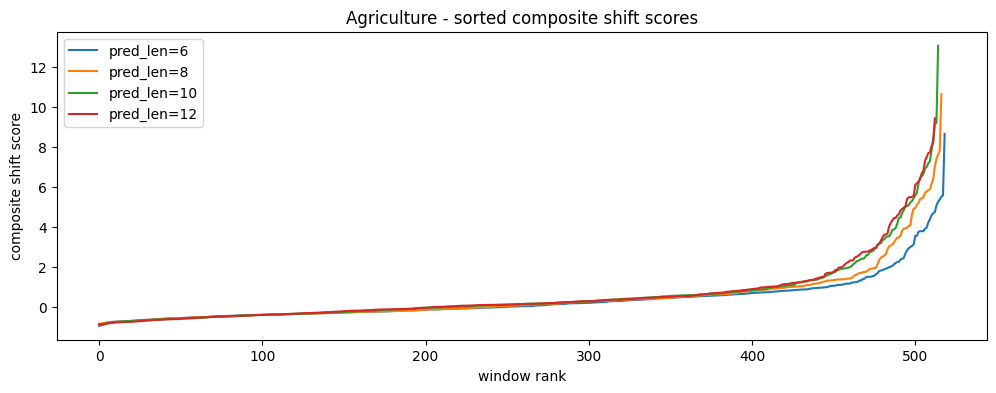

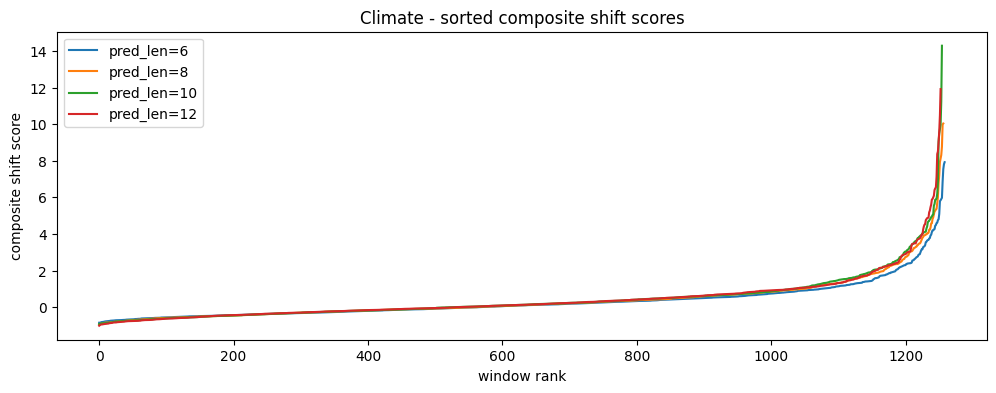

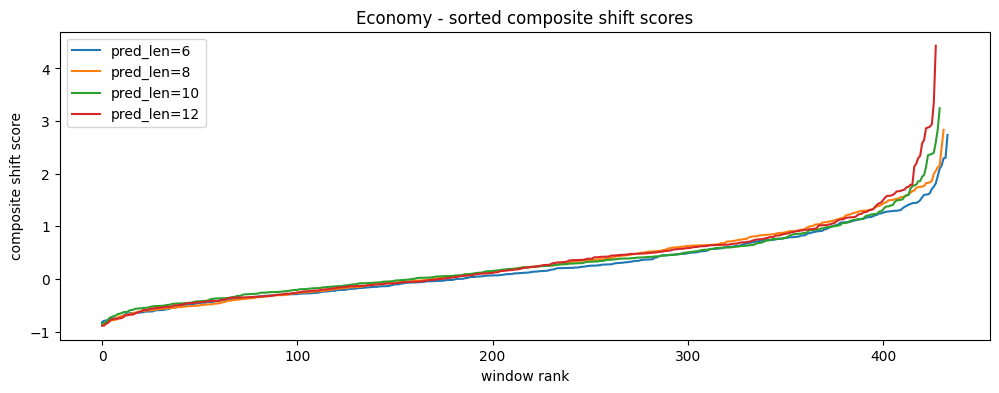

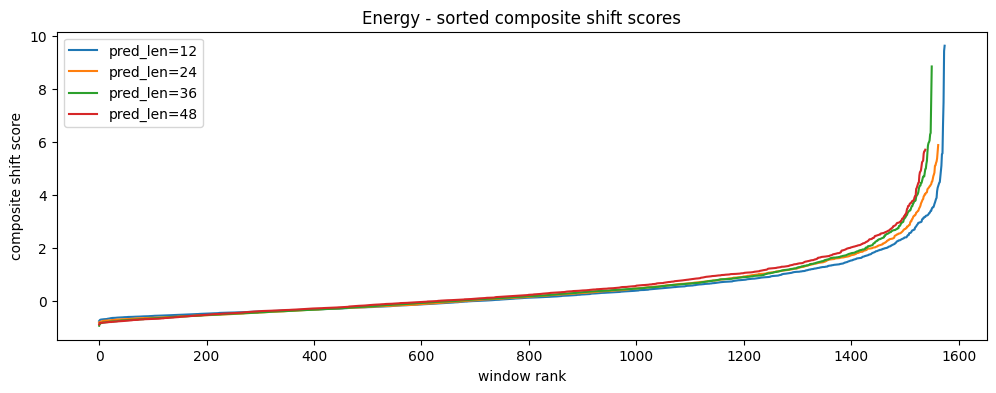

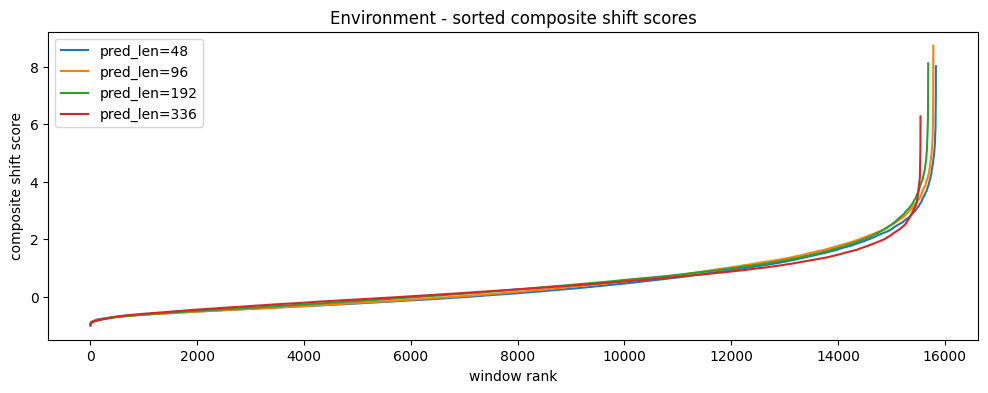

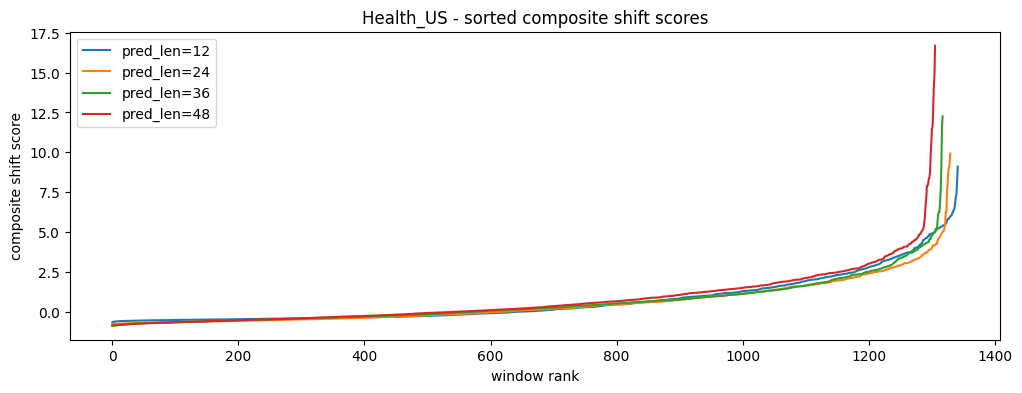

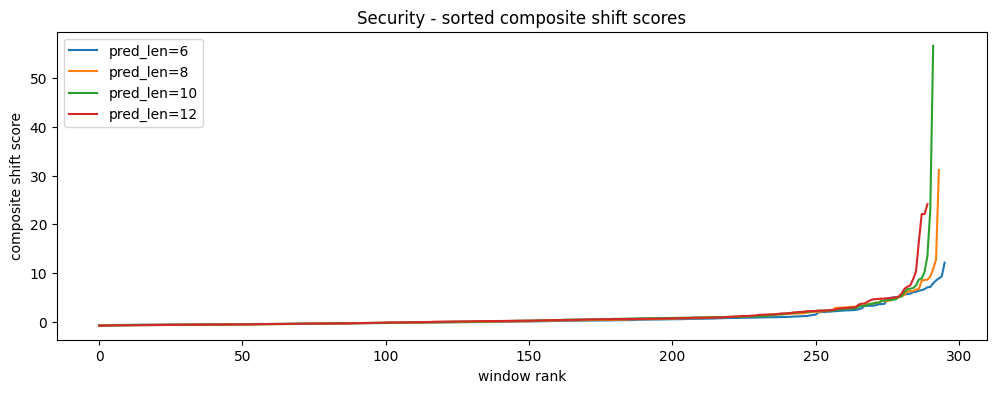

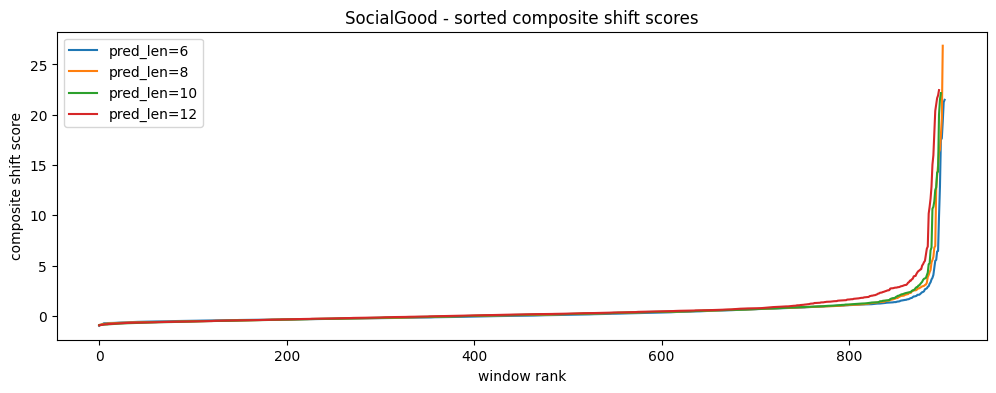

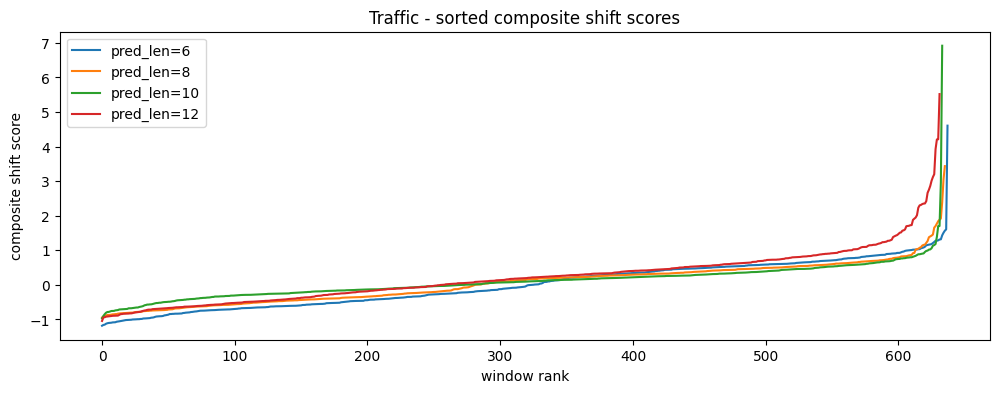

In [31]:
def plot_score_distribution(domain: str):
    sub = results_df[results_df["domain"] == domain].copy()
    pred_lens = sorted(sub["pred_len"].unique())

    plt.figure(figsize=(12, 4))
    for pred_len in pred_lens:
        arr = sub.loc[sub["pred_len"] == pred_len, "composite_shift_score"].values
        arr = np.sort(arr)
        plt.plot(arr, label=f"pred_len={pred_len}")
    plt.title(f"{domain} - sorted composite shift scores")
    plt.xlabel("window rank")
    plt.ylabel("composite shift score")
    plt.legend()
    plt.show()

for domain in DOMAIN_CONFIG.keys():
    plot_score_distribution(domain)

## 6. 개별 구간 시각화 함수

입력 구간과 미래 구간을 함께 그리고, 앞뒤 문맥까지 붙여서 갑작스러운 변화를 직관적으로 볼 수 있게 합니다.


In [32]:

def load_target_series(domain: str):
    cfg = DOMAIN_CONFIG[domain]
    csv_path = DATA_ROOT / cfg["csv"]
    df = load_domain_csv(csv_path)
    return df

def plot_window(domain: str, seq_len: int, pred_len: int, window_idx: int, context_before: int = 40, context_after: int = 40):
    df = load_target_series(domain)
    series = df[TARGET_COL].values.astype(np.float64)
    dates = pd.to_datetime(df["start_date"]) if "start_date" in df.columns else pd.RangeIndex(len(df))

    x_start = window_idx
    x_end = window_idx + seq_len
    y_start = x_end
    y_end = x_end + pred_len

    left = max(0, x_start - context_before)
    right = min(len(series), y_end + context_after)

    plot_idx = np.arange(left, right)
    plot_dates = dates.iloc[left:right] if hasattr(dates, "iloc") else plot_idx
    plot_values = series[left:right]

    plt.figure(figsize=(14, 4))
    plt.plot(plot_dates, plot_values, marker="o", linewidth=1.5, markersize=3)

    plt.axvspan(plot_dates.iloc[x_start-left], plot_dates.iloc[x_end-left-1], alpha=0.20, label="input window")
    plt.axvspan(plot_dates.iloc[y_start-left], plot_dates.iloc[y_end-left-1], alpha=0.35, label="forecast horizon")

    plt.axvline(plot_dates.iloc[x_end-left-1], linestyle="--", linewidth=1)
    plt.title(f"{domain} | seq_len={seq_len}, pred_len={pred_len}, window_idx={window_idx}")
    plt.xlabel("time")
    plt.ylabel(TARGET_COL)
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

def inspect_top_episode(rank: int = 0):
    row = top_episodes_df.iloc[rank]
    display(row[episode_cols_to_show].to_frame().T)
    plot_window(
        domain=row["domain"],
        seq_len=int(row["seq_len"]),
        pred_len=int(row["pred_len"]),
        window_idx=int(row["representative_window_idx"]),
    )


## 6A. Time-axis difficulty / hard region 시각화

In [ ]:

def plot_time_difficulty(domain: str, figsize=(14, 4)):
    sub = (
        time_difficulty_df[time_difficulty_df["domain"] == domain]
        .sort_values("time_idx")
        .reset_index(drop=True)
    )

    if sub.empty:
        print(f"No difficulty data for domain={domain}")
        return

    x = sub["start_date"]
    y = sub["difficulty_score"]
    threshold = float(sub["difficulty_score"].dropna().quantile(HARD_REGION_QUANTILE))

    plt.figure(figsize=figsize)
    plt.plot(x, y, linewidth=1.5, label="difficulty_score")
    plt.axhline(threshold, linestyle="--", linewidth=1, label=f"q{int(HARD_REGION_QUANTILE * 100)} threshold")

    hard_sub = hard_region_df[hard_region_df["domain"] == domain]
    for _, row in hard_sub.iterrows():
        plt.axvspan(row["region_start_date"], row["region_end_date"], alpha=0.18)

    plt.title(f"{domain} | time-axis difficulty")
    plt.xlabel("time")
    plt.ylabel("difficulty_score")
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()


def inspect_hard_region(domain: str, rank: int = 0, context_before: int = 40, context_after: int = 40):
    sub = (
        hard_region_df[hard_region_df["domain"] == domain]
        .sort_values(["peak_difficulty", "mean_difficulty"], ascending=[False, False])
        .reset_index(drop=True)
    )

    if sub.empty:
        print(f"No hard regions for domain={domain}")
        return

    row = sub.iloc[rank]
    display(row[hard_region_cols_to_show].to_frame().T)

    df = load_target_series(domain)
    series = df[TARGET_COL].values.astype(np.float64)
    dates = pd.to_datetime(df["start_date"]) if "start_date" in df.columns else pd.RangeIndex(len(df))

    region_start = int(row["region_start_idx"])
    region_end = int(row["region_end_idx"])

    left = max(0, region_start - context_before)
    right = min(len(series), region_end + context_after + 1)

    plot_dates = dates.iloc[left:right] if hasattr(dates, "iloc") else np.arange(left, right)
    plot_values = series[left:right]

    plt.figure(figsize=(14, 4))
    plt.plot(plot_dates, plot_values, marker="o", linewidth=1.5, markersize=3)
    plt.axvspan(
        plot_dates.iloc[region_start - left],
        plot_dates.iloc[region_end - left],
        alpha=0.30,
        label="hard region",
    )
    plt.axvline(plot_dates.iloc[region_start - left], linestyle="--", linewidth=1)
    plt.axvline(plot_dates.iloc[region_end - left], linestyle="--", linewidth=1)

    plt.title(f"{domain} | hard region rank={rank}")
    plt.xlabel("time")
    plt.ylabel(TARGET_COL)
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:

# 예시: 도메인 하나를 선택해서 difficulty 곡선과 가장 어려운 구간 확인
plot_time_difficulty("SocialGood")
inspect_hard_region("SocialGood", rank=0)


In [ ]:

# 예시: 각 도메인에서 가장 어려운 구간만 빠르게 확인
for domain in hard_region_df["domain"].drop_duplicates():
    inspect_hard_region(domain, rank=0)


,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,input_mean,target_mean,input_std,target_std,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,mean_shift_rz,volatility_shift_rz,wasserstein_rz,trend_mismatch_rz,residual_burst_rz,drift_error_rz,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,is_extreme_by_percentile,is_extreme_by_robust_z,is_extreme,domain,pred_len,seq_len,seq_to_pred_ratio
30,1186,2020-06-22 00:00:00,2021-02-21 00:00:00,2021-02-22 00:00:00,2022-01-23 00:00:00,1.200482,1.920659,0.200261,0.903188,3.596196,3.51006,3.600691,3.531991,53.683923,13.304587,7.09048,6.591882,8.178935,24.656746,35.000667,3.385386,7.287099,29.828707,3.385386,14.743057,True,True,True,Health_US,48,36,0.75


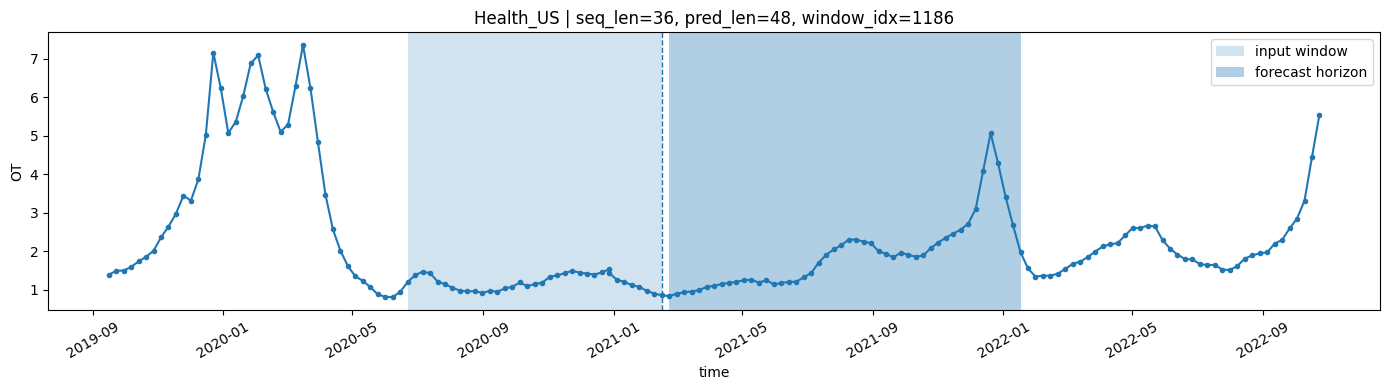

In [37]:
# 예시: 가장 급격한 변화 episode 시각화
inspect_top_episode(30)

## 7. 특정 도메인만 집중해서 보기

In [43]:

FOCUS_DOMAIN = "SocialGood"

focus_df = (
    top_episodes_df[top_episodes_df["domain"] == FOCUS_DOMAIN]
    .sort_values("peak_score", ascending=False)
    .reset_index(drop=True)
)

focus_df[episode_cols_to_show].head(20)


,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
0,SocialGood,8,8,856,2019-05-01,2019-12-31,2020-01-01,2020-08-31,33.470212,38.328306,12.075871,26.855713,19.676124,13.911446,19.676124,5.202821,23.718216,21.899147,True
1,SocialGood,8,12,853,2019-02-01,2019-09-30,2019-10-01,2020-09-30,21.915255,39.945734,5.211151,22.445805,12.000000,12.198625,12.000000,4.333333,25.018474,13.875001,True
2,SocialGood,8,10,854,2019-03-01,2019-10-31,2019-11-01,2020-08-31,27.772044,33.584321,7.893617,22.145584,14.354266,13.606675,14.354266,4.772970,26.191240,17.845606,True
3,SocialGood,8,12,848,2018-09-01,2019-04-30,2019-05-01,2020-04-30,10.037585,48.403921,1.360023,21.913095,2.457366,7.790502,2.801397,8.404190,23.335904,5.701089,True
4,SocialGood,8,12,854,2019-03-01,2019-10-31,2019-11-01,2020-10-31,23.558893,35.209721,7.148528,21.655078,14.053746,12.374512,14.053746,3.623922,22.574481,17.987027,True
5,SocialGood,8,10,855,2019-04-01,2019-11-30,2019-12-01,2020-09-30,29.032062,29.599895,9.594080,21.484002,16.775582,13.189118,16.775582,4.216813,23.195860,21.129900,True
6,SocialGood,8,6,856,2019-05-01,2019-12-31,2020-01-01,2020-06-30,35.839891,21.818527,13.968030,21.482601,18.714391,15.970445,18.714391,7.378546,9.401286,20.559026,True
7,SocialGood,8,6,858,2019-07-01,2020-02-29,2020-03-01,2020-08-31,31.816937,23.241381,13.950784,21.240253,22.635871,9.783748,22.635871,5.375494,12.956882,20.536069,True
8,SocialGood,8,12,852,2019-01-01,2019-08-31,2019-09-01,2020-08-31,18.938350,40.080546,2.990542,21.016105,9.236407,11.251926,9.509895,4.773594,24.182053,9.161820,True
9,SocialGood,8,12,855,2019-04-01,2019-11-30,2019-12-01,2020-11-30,24.484470,30.239246,8.470925,20.380962,15.797770,12.136928,15.797770,3.116775,19.497512,20.793777,True


,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
0,SocialGood,8,8,856,2019-05-01 00:00:00,2019-12-31 00:00:00,2020-01-01 00:00:00,2020-08-31 00:00:00,33.470212,38.328306,12.075871,26.855713,19.676124,13.911446,19.676124,5.202821,23.718216,21.899147,True


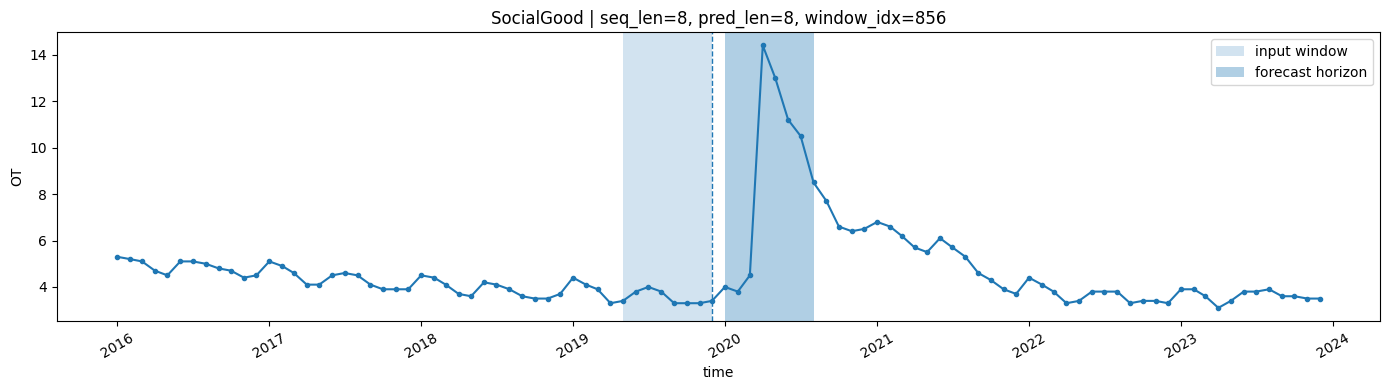

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
1,SocialGood,8,12,853,2019-02-01 00:00:00,2019-09-30 00:00:00,2019-10-01 00:00:00,2020-09-30 00:00:00,21.915255,39.945734,5.211151,22.445805,12.0,12.198625,12.0,4.333333,25.018474,13.875001,True


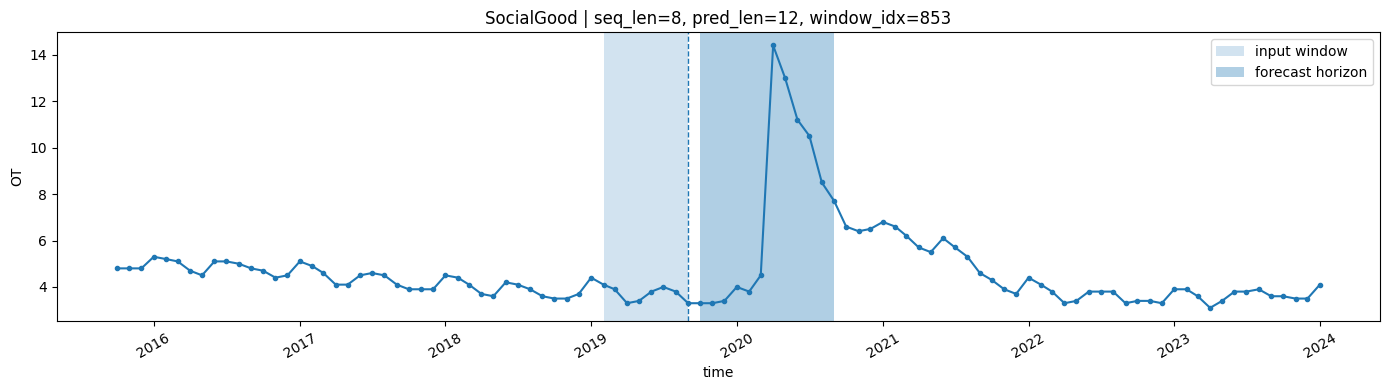

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
2,SocialGood,8,10,854,2019-03-01 00:00:00,2019-10-31 00:00:00,2019-11-01 00:00:00,2020-08-31 00:00:00,27.772044,33.584321,7.893617,22.145584,14.354266,13.606675,14.354266,4.77297,26.19124,17.845606,True


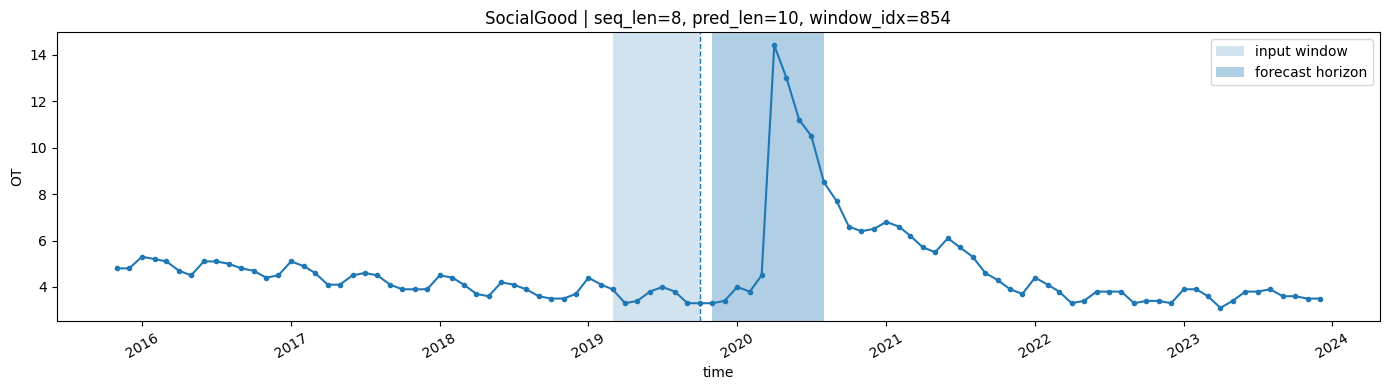

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
3,SocialGood,8,12,848,2018-09-01 00:00:00,2019-04-30 00:00:00,2019-05-01 00:00:00,2020-04-30 00:00:00,10.037585,48.403921,1.360023,21.913095,2.457366,7.790502,2.801397,8.40419,23.335904,5.701089,True


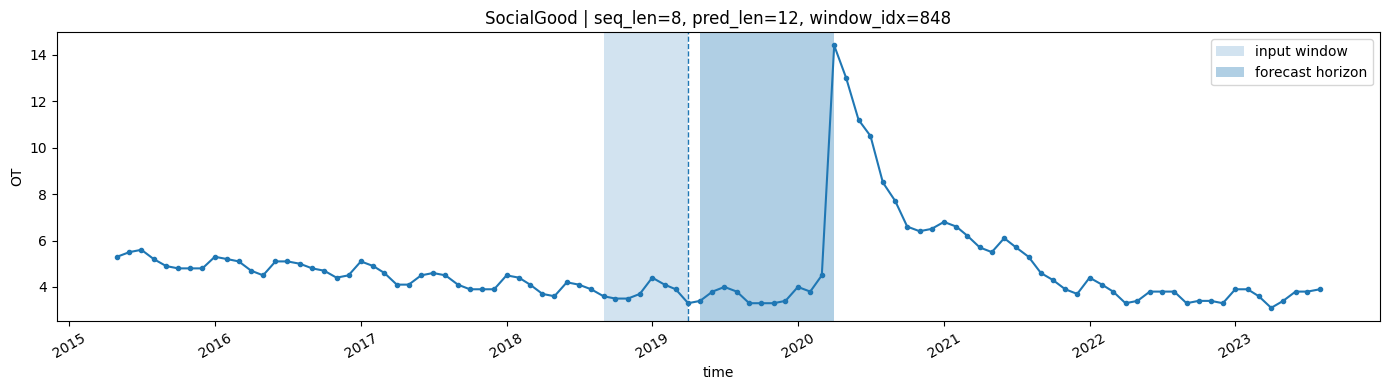

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
4,SocialGood,8,12,854,2019-03-01 00:00:00,2019-10-31 00:00:00,2019-11-01 00:00:00,2020-10-31 00:00:00,23.558893,35.209721,7.148528,21.655078,14.053746,12.374512,14.053746,3.623922,22.574481,17.987027,True


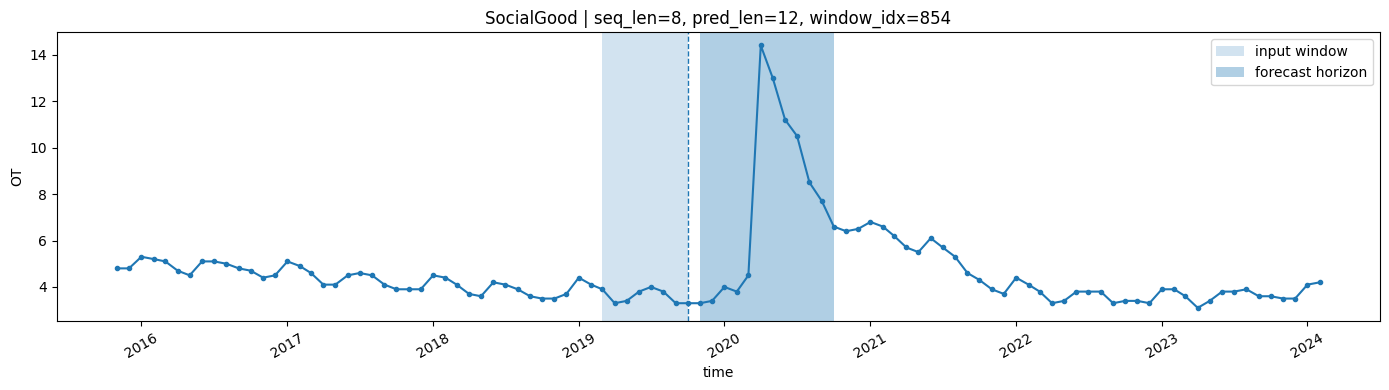

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
5,SocialGood,8,10,855,2019-04-01 00:00:00,2019-11-30 00:00:00,2019-12-01 00:00:00,2020-09-30 00:00:00,29.032062,29.599895,9.59408,21.484002,16.775582,13.189118,16.775582,4.216813,23.19586,21.1299,True


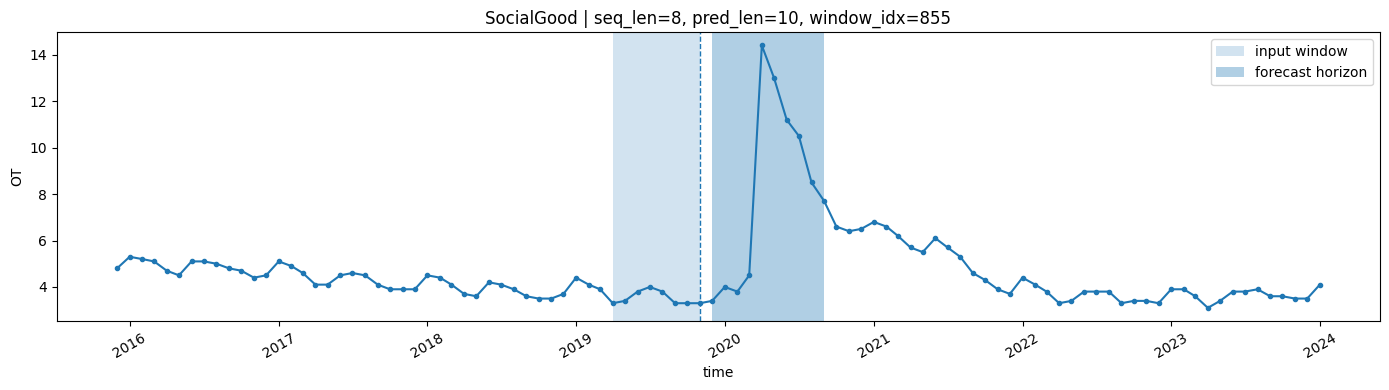

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
6,SocialGood,8,6,856,2019-05-01 00:00:00,2019-12-31 00:00:00,2020-01-01 00:00:00,2020-06-30 00:00:00,35.839891,21.818527,13.96803,21.482601,18.714391,15.970445,18.714391,7.378546,9.401286,20.559026,True


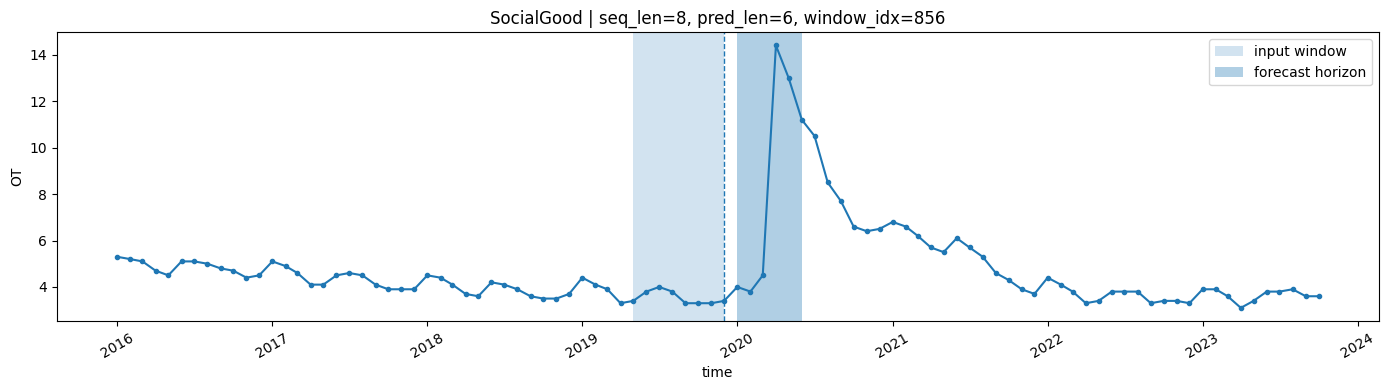

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
7,SocialGood,8,6,858,2019-07-01 00:00:00,2020-02-29 00:00:00,2020-03-01 00:00:00,2020-08-31 00:00:00,31.816937,23.241381,13.950784,21.240253,22.635871,9.783748,22.635871,5.375494,12.956882,20.536069,True


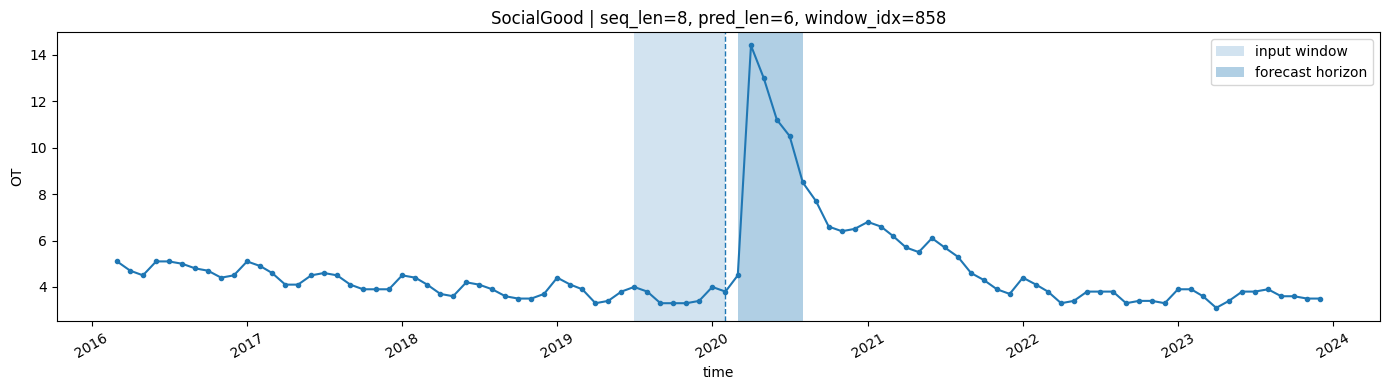

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
8,SocialGood,8,12,852,2019-01-01 00:00:00,2019-08-31 00:00:00,2019-09-01 00:00:00,2020-08-31 00:00:00,18.93835,40.080546,2.990542,21.016105,9.236407,11.251926,9.509895,4.773594,24.182053,9.16182,True


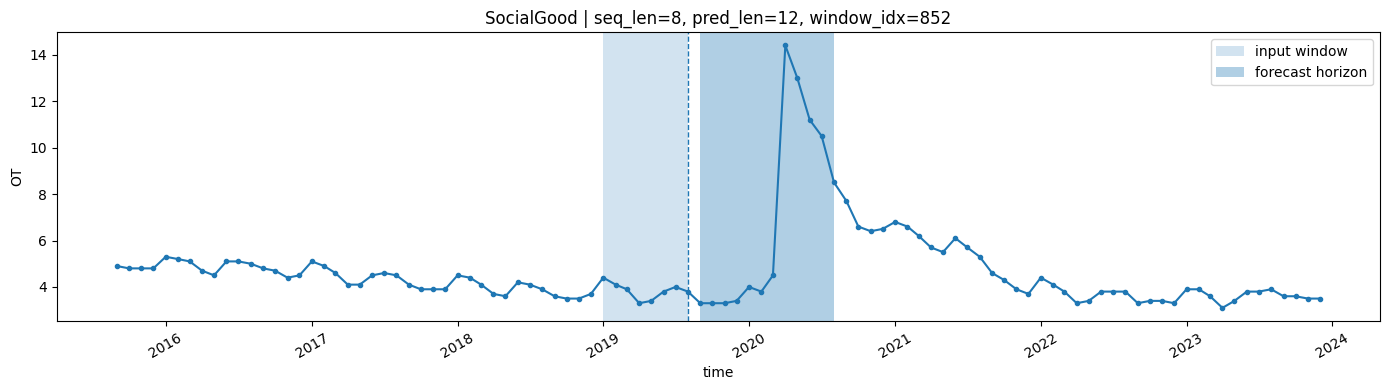

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
9,SocialGood,8,12,855,2019-04-01 00:00:00,2019-11-30 00:00:00,2019-12-01 00:00:00,2020-11-30 00:00:00,24.48447,30.239246,8.470925,20.380962,15.79777,12.136928,15.79777,3.116775,19.497512,20.793777,True


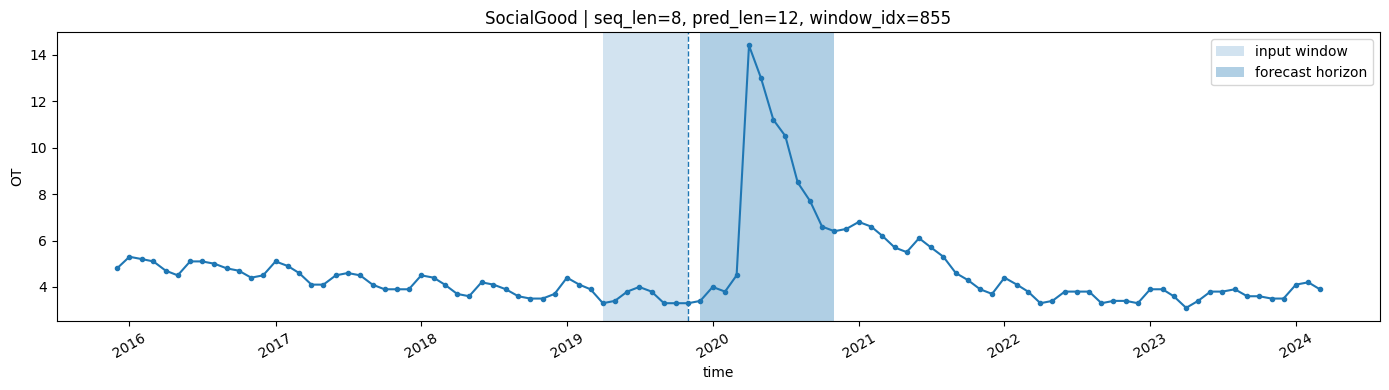

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
10,SocialGood,8,10,856,2019-05-01 00:00:00,2019-12-31 00:00:00,2020-01-01 00:00:00,2020-10-31 00:00:00,29.497661,25.700136,9.566253,20.006088,18.474746,12.58383,18.474746,3.973064,19.938731,21.076155,True


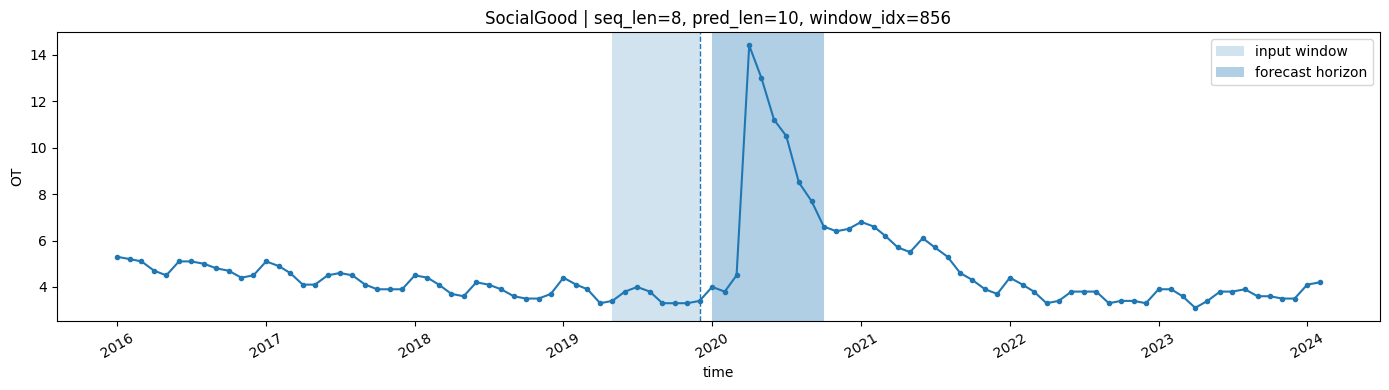

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
11,SocialGood,8,8,857,2019-06-01 00:00:00,2020-01-31 00:00:00,2020-02-01 00:00:00,2020-09-30 00:00:00,28.770095,26.774585,7.917759,19.630957,18.772234,10.946972,18.772234,5.039526,15.71341,15.139576,True


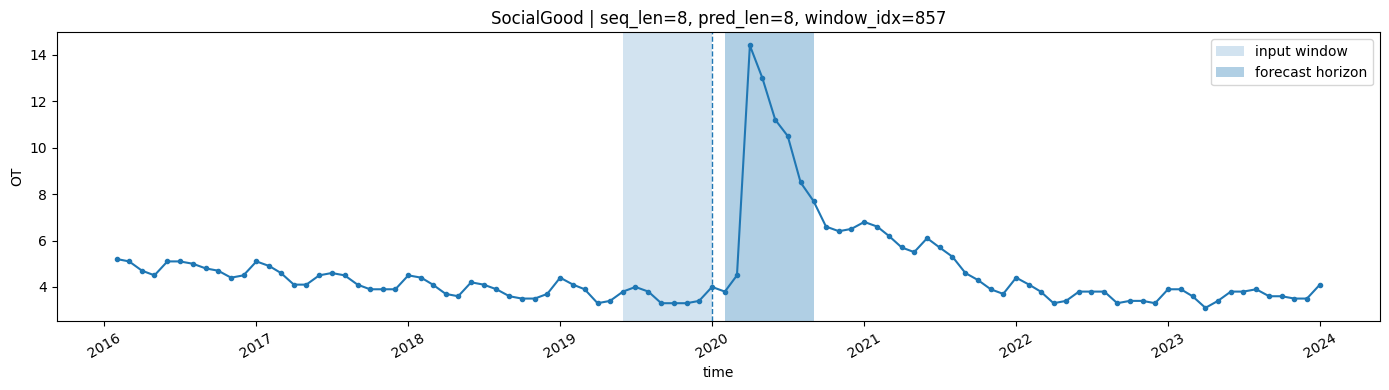

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
12,SocialGood,8,6,855,2019-04-01 00:00:00,2019-11-30 00:00:00,2019-12-01 00:00:00,2020-05-31 00:00:00,30.952062,21.87971,10.907769,19.305404,13.414354,16.002772,13.414354,8.891975,7.621093,16.485294,True


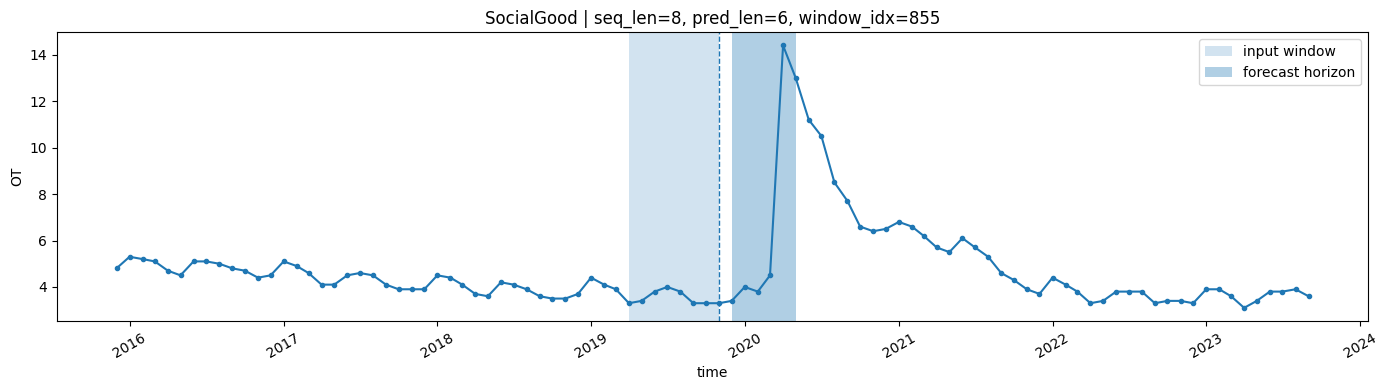

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
13,SocialGood,8,12,849,2018-10-01 00:00:00,2019-05-31 00:00:00,2019-06-01 00:00:00,2020-05-31 00:00:00,13.584932,34.971245,3.446799,18.084204,4.655687,9.516908,4.772664,7.018624,15.052776,10.130213,True


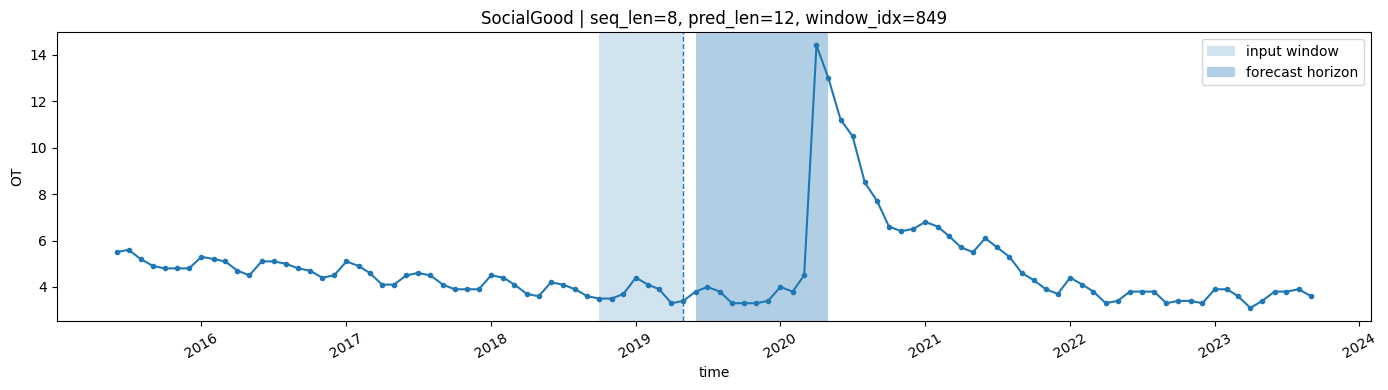

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
14,SocialGood,8,8,855,2019-04-01 00:00:00,2019-11-30 00:00:00,2019-12-01 00:00:00,2020-07-31 00:00:00,32.336506,17.580096,11.207942,17.982516,16.775582,14.846956,16.775582,6.14188,8.382233,20.488211,True


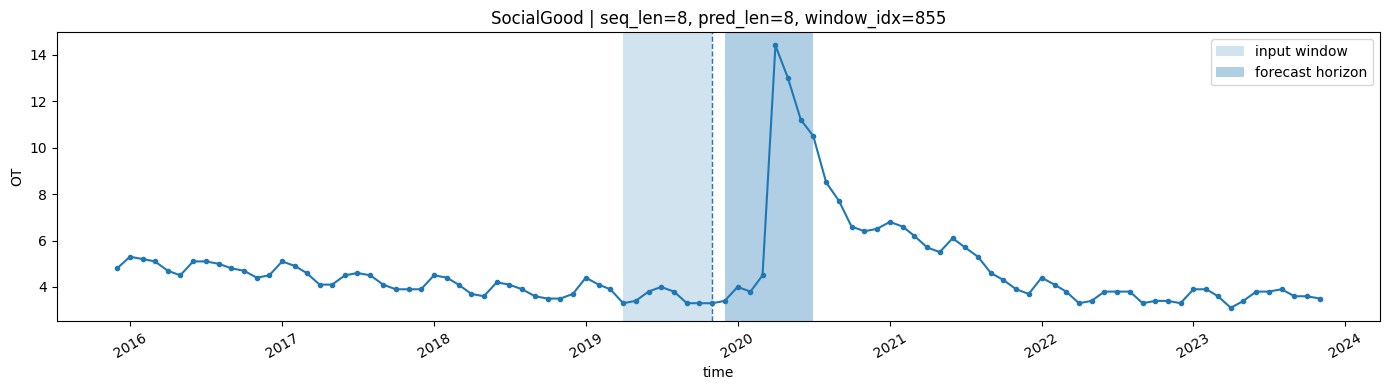

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
15,SocialGood,8,6,857,2019-06-01 00:00:00,2020-01-31 00:00:00,2020-02-01 00:00:00,2020-07-31 00:00:00,32.800516,16.398325,11.3428,17.656553,20.004119,12.551188,20.004119,4.451581,8.615329,17.064395,True


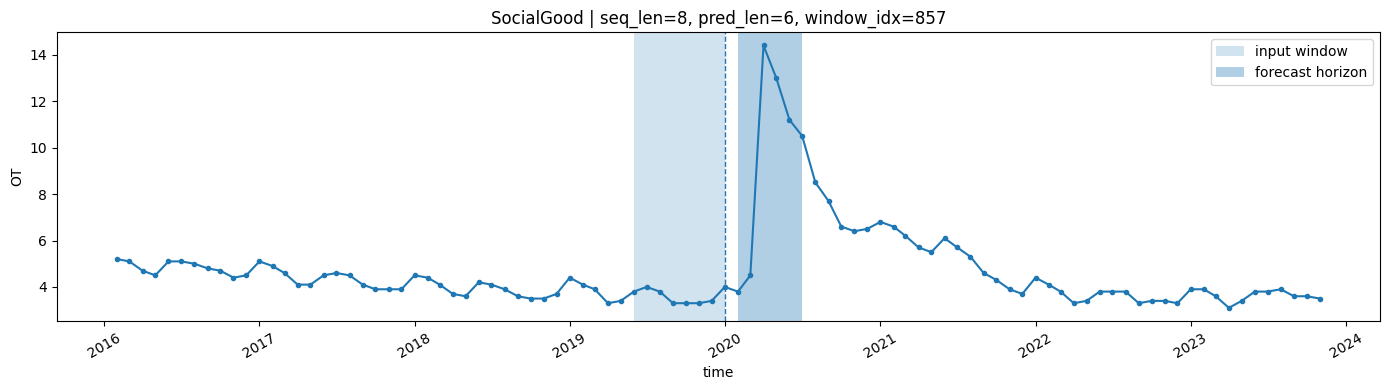

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
16,SocialGood,8,6,854,2019-03-01 00:00:00,2019-10-31 00:00:00,2019-11-01 00:00:00,2020-04-30 00:00:00,21.267757,27.404123,5.705869,17.497548,6.953216,13.036657,6.953216,10.164659,10.489387,9.560672,True


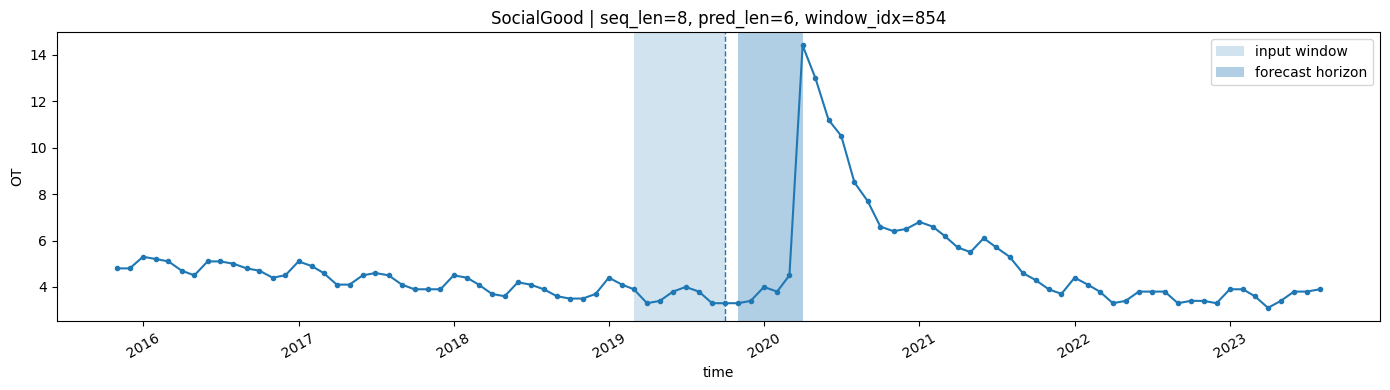

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
17,SocialGood,8,8,858,2019-07-01 00:00:00,2020-02-29 00:00:00,2020-03-01 00:00:00,2020-10-31 00:00:00,27.771987,18.112789,9.325692,16.52979,19.948124,9.475805,19.948124,4.283597,10.206223,17.428361,True


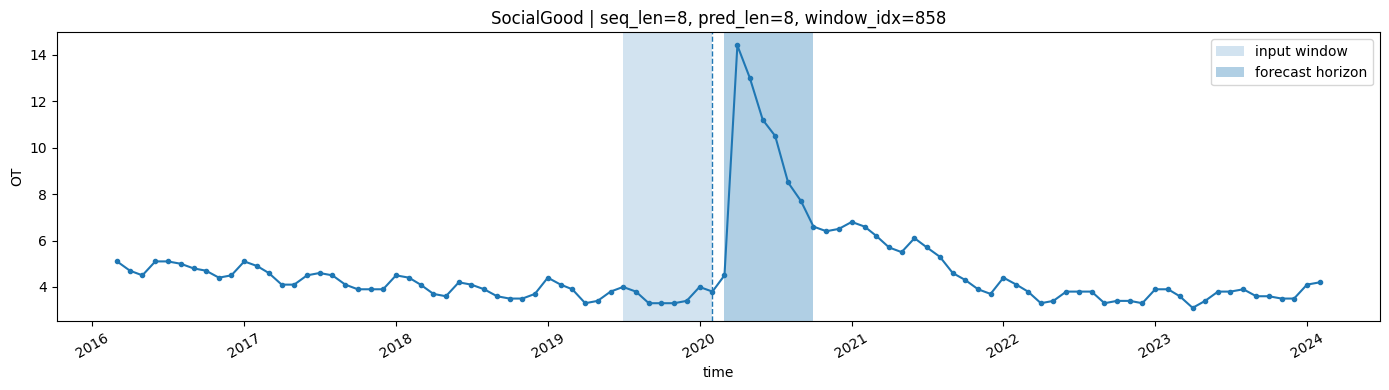

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
18,SocialGood,8,8,854,2019-03-01 00:00:00,2019-10-31 00:00:00,2019-11-01 00:00:00,2020-06-30 00:00:00,28.978607,17.906663,8.310063,16.282412,12.727921,14.822253,12.727921,6.982679,7.956451,15.777319,True


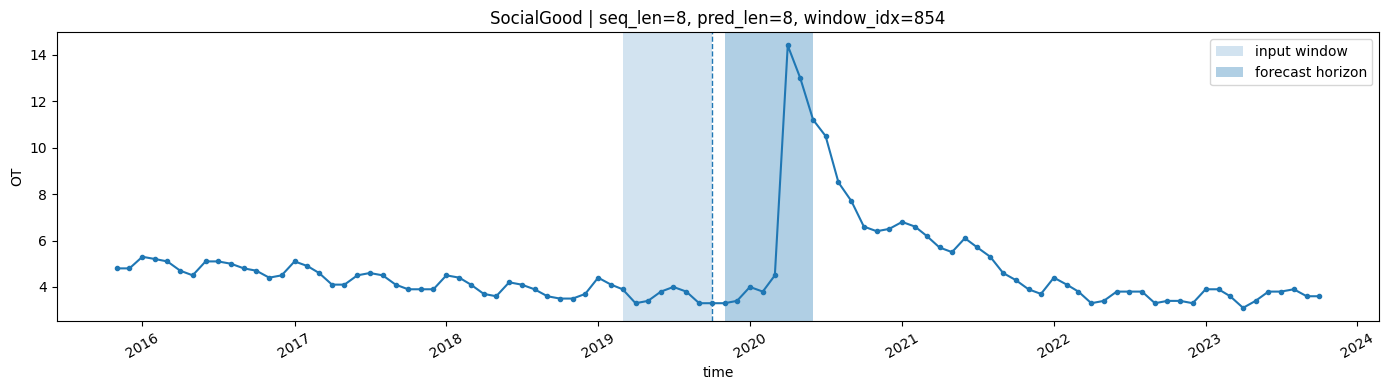

,domain,seq_len,pred_len,window_idx,input_start_date,input_end_date,target_start_date,target_end_date,distribution_score,structural_break_score,forecast_failure_score,composite_shift_score,mean_shift,volatility_shift,wasserstein,trend_mismatch,residual_burst,drift_error,is_extreme
19,SocialGood,8,12,856,2019-05-01 00:00:00,2019-12-31 00:00:00,2020-01-01 00:00:00,2020-12-31 00:00:00,24.961972,19.258112,8.196902,15.9744,17.232375,11.707888,17.232375,1.513548,13.740938,20.212171,True


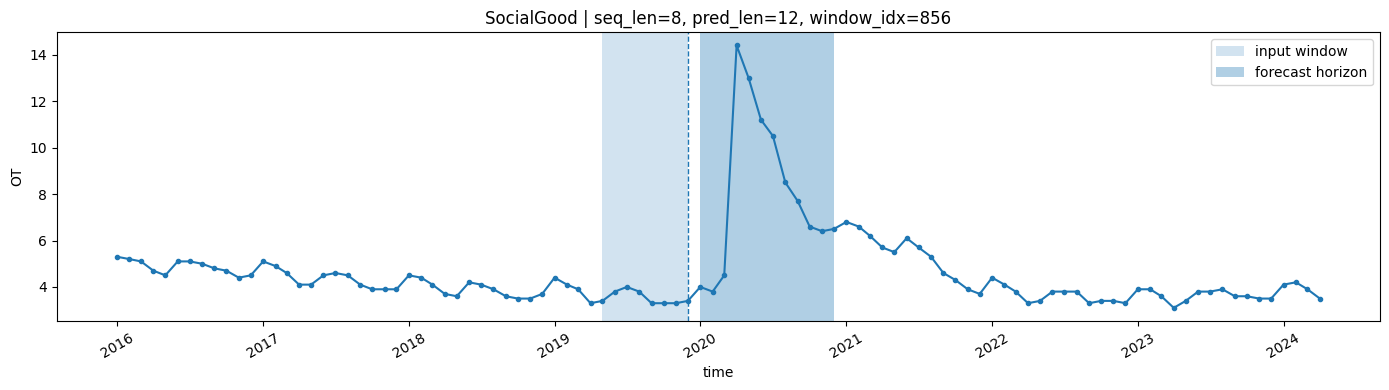

In [44]:

# 예시: 특정 도메인 상위 5개 episode 시각화
for i in range(min(20, len(focus_df))):
    row = focus_df.iloc[i]
    print(f"=== rank {i} ===")
    display(row[episode_cols_to_show].to_frame().T)
    plot_window(
        domain=row["domain"],
        seq_len=int(row["seq_len"]),
        pred_len=int(row["pred_len"]),
        window_idx=int(row["representative_window_idx"]),
    )


## 8. CSV로 저장

추후 보고서나 다른 실험에서 바로 재활용할 수 있도록 저장합니다.


In [ ]:

output_dir = REPO_ROOT / "outputs" / "shift_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(output_dir / "all_window_shift_scores.csv", index=False)
summary_df.to_csv(output_dir / "domain_predlen_shift_summary.csv", index=False)
episode_df.to_csv(output_dir / "all_extreme_episodes.csv", index=False)
episode_summary_df.to_csv(output_dir / "episode_summary.csv", index=False)
top_episodes_df.to_csv(output_dir / "top_shift_episodes.csv", index=False)

time_difficulty_df.to_csv(output_dir / "time_axis_difficulty.csv", index=False)
hard_region_df.to_csv(output_dir / "hard_regions.csv", index=False)
hard_region_summary_df.to_csv(output_dir / "hard_region_summary.csv", index=False)
top_hard_regions_df.to_csv(output_dir / "top_hard_regions.csv", index=False)

print("Saved:")
print("-", output_dir / "all_window_shift_scores.csv")
print("-", output_dir / "domain_predlen_shift_summary.csv")
print("-", output_dir / "all_extreme_episodes.csv")
print("-", output_dir / "episode_summary.csv")
print("-", output_dir / "top_shift_episodes.csv")
print("-", output_dir / "time_axis_difficulty.csv")
print("-", output_dir / "hard_regions.csv")
print("-", output_dir / "hard_region_summary.csv")
print("-", output_dir / "top_hard_regions.csv")


## 9. 해석 팁

이 score는 **진짜 예측 불가능성**을 직접 증명하는 값은 아니고,  
적어도 다음 상황을 잘 잡아내는 **후보 탐색 지표**로 보는 것이 적절합니다.

- 입력 구간과 미래 구간의 분포가 크게 달라지는 경우
- 입력 마지막 지점에서 미래 첫 지점으로 점프가 큰 경우
- 평균은 비슷해도 분산/형태/추세가 달라지는 경우

추가로 원하시면 다음 확장도 가능합니다.

1. **모델 오차와 결합**
   - 실제 DLinear / PatchTST / GPT4TS 예측 오차가 큰 구간과 겹치는지 비교

2. **멀티변수 기반 drift**
   - 현재는 `OT` 기준이지만, 전체 feature 분포 변화를 multivariate distance로 계산 가능

3. **change-point detection 결합**
   - ruptures / bayesian online change point detection 같은 방법과 결합 가능

4. **시각화 개선**
   - Plotly로 interactive explorer 제작
   - domain / pred_len / rank를 선택하는 widget 추가
